"""
Train–Test Distribution Comparison for Thermal Comfort Dataset
=============================================================

This notebook performs a comprehensive comparison of the **training** and **testing**
subsets used in the thermal comfort prediction project.  
It automatically processes all three targets:

- ``thermal_sensation``
- ``TSV_3p``
- ``thermal_preference``

The goal is to evaluate whether the train and test sets share similar
distributions across both categorical and numerical features.  
This ensures that models are trained and evaluated on representative and
balanced data.

Main Features
-------------

1. **Automatic Target Handling**
   The notebook loops over all three defined targets and loads the corresponding
   split indices from:
   ``kfold_results_unified/<target>/splits/<target>_split_indices.json``.

2. **Categorical Feature Distribution Analysis**
   - Computes count and percentage distributions for train and test.
   - Produces clean formatted tables.
   - Generates and saves bar plots visualizing train/test percentages.
   - Saves all results as CSV + JSON + PNG.

3. **Numerical Feature Distribution Analysis**
   - Computes descriptive statistics (mean, standard deviation, mean shift).
   - Generates density (KDE) plots to compare train/test distributions.
   - Saves all plots and statistics automatically.


4. **Structured Output**
   For each target, results are saved in:
   ``analysis_results_distributions/<target>/``

   Files include:
   - ``cat_<column>.csv`` and ``cat_<column>.png``
   - ``num_<column>.png``
   - ``summary.json``
   - Overall summary across all targets: ``global_summary.json``

Purpose
-------

This analysis helps verify the representativeness and stability of the training
and testing partitions.  
It is essential for understanding the generalization ability of machine learning
models and for explaining differences in performance between train/test data.

"""


Imports & Config

In [9]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid")

DATASET_PATH = "Data/ASHRAE_2022_Clean_api.csv"

TARGETS = ["thermal_sensation", "TSV_3p" , "thermal_preference"]

SPLIT_BASE = Path("kfold_results_unified")
OUTPUT_BASE = Path("analysis/analysis_results_distributions")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)



Load Split Indices

In [10]:
def load_split_indices(target):
    split_path = SPLIT_BASE / target / "splits" / f"{target}_split_indices.json"
    if not split_path.exists():
        raise FileNotFoundError(f"Missing split file: {split_path}")

    with open(split_path, "r") as f:
        split = json.load(f)

    return split["train_idx"], split["test_idx"]


Categorical Indices

In [11]:
def cat_distribution(df, train_idx, test_idx, col):
    train_series = df.loc[train_idx, col]
    test_series  = df.loc[test_idx, col]

    train_counts = train_series.value_counts().sort_index()
    test_counts  = test_series.value_counts().sort_index()

    all_idx = train_counts.index.union(test_counts.index)

    out = pd.DataFrame({
        "train_count": train_counts.reindex(all_idx, fill_value=0),
        "test_count":  test_counts.reindex(all_idx, fill_value=0)
    })
    out["train_pct"] = (out["train_count"] / out["train_count"].sum() * 100).round(2)
    out["test_pct"]  = (out["test_count"]  / out["test_count"].sum()  * 100).round(2)

    return out


Numeric statistics

In [12]:
def compute_numeric_stats(df, train_idx, test_idx, col):
    return {
        "train_mean": float(df.loc[train_idx, col].mean()),
        "test_mean":  float(df.loc[test_idx, col].mean()),
        "train_std":  float(df.loc[train_idx, col].std()),
        "test_std":   float(df.loc[test_idx, col].std()),
        "mean_shift": float(df.loc[test_idx, col].mean() - df.loc[train_idx, col].mean())
    }


Plot categorical distributions

In [13]:
def plot_cat_distribution(df_stats, col, save_path=None):
    plt.figure(figsize=(7,4))
    df_stats[["train_pct", "test_pct"]].plot(kind="bar", color=["#4C72B0", "#55A868"])
    plt.title(f"Train/Test Distribution — {col}")
    plt.ylabel("Percentage (%)")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()


Plot numeric distributions

In [14]:
def plot_numeric_distribution(df, train_idx, test_idx, col, save_path=None):
    plt.figure(figsize=(7,4))
    sns.kdeplot(df.loc[train_idx, col], fill=True, label="train")
    sns.kdeplot(df.loc[test_idx, col], fill=True, label="test")

    plt.title(f"Train/Test — {col}")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()


MAIN FUNCTION

In [15]:
def run_distribution_analysis(df, target):
    print("\n====================================")
    print(f" TRAIN/TEST DISTRIBUTION — {target}")
    print("====================================")

    out_dir = OUTPUT_BASE / target
    out_dir.mkdir(exist_ok=True)

    train_idx, test_idx = load_split_indices(target)

    cat_cols = ["Sexe", "Season", "Building_type", "cooling type", "Climate"]
    num_cols = ["Tair", "RH", "vel", "clo", "Met", "Tout", "Trm_ema_28"]

    summary = {
        "target": target,
        "categorical": {},
        "numeric": {}
    }

    # ------------------------------------
    # CATEGORICAL FEATURES
    # ------------------------------------
    print("\n### CATEGORICAL DISTRIBUTIONS ###")
    for col in cat_cols:
        stats = cat_distribution(df, train_idx, test_idx, col)
        display(stats)

        stats.to_csv(out_dir / f"cat_{col}.csv")

        plot_cat_distribution(stats, col, save_path=out_dir / f"cat_{col}.png")

        summary["categorical"][col] = stats.to_dict()

    # ------------------------------------
    # NUMERIC FEATURES
    # ------------------------------------
    print("\n### NUMERICAL DISTRIBUTIONS ###")
    for col in num_cols:
        stats = compute_numeric_stats(df, train_idx, test_idx, col)
        print(f"\n-- {col} --")
        print(stats)

        summary["numeric"][col] = stats

        plot_numeric_distribution(df, train_idx, test_idx, col, save_path=out_dir / f"num_{col}.png")

    # ------------------------------------
    # SAVE SUMMARY JSON
    # ------------------------------------
    with open(out_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=4)

    print(f"\nSaved results to: {out_dir}")
    return summary


RUN automatic for ALL targets


 TRAIN/TEST DISTRIBUTION — thermal_sensation

### CATEGORICAL DISTRIBUTIONS ###


,train_count,test_count,train_pct,test_pct
Sexe,,,,
female,6123,1525,50.28,50.08
male,6056,1520,49.72,49.92


<Figure size 700x400 with 0 Axes>

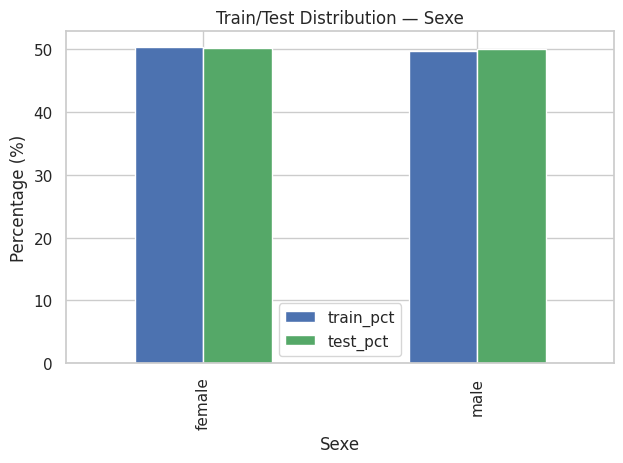

,train_count,test_count,train_pct,test_pct
Season,,,,
cool/dry,1532,391,12.58,12.84
hot/wet,1894,454,15.55,14.91
summer,5849,1471,48.03,48.31
winter,2904,729,23.84,23.94


<Figure size 700x400 with 0 Axes>

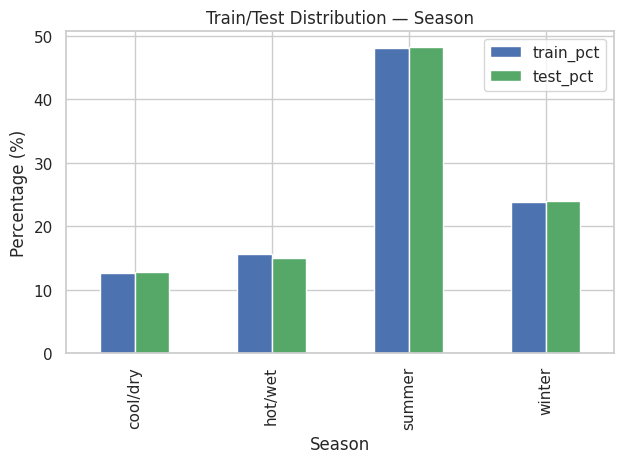

,train_count,test_count,train_pct,test_pct
Building_type,,,,
multifamily housing,1366,344,11.22,11.3
office,10813,2701,88.78,88.7


<Figure size 700x400 with 0 Axes>

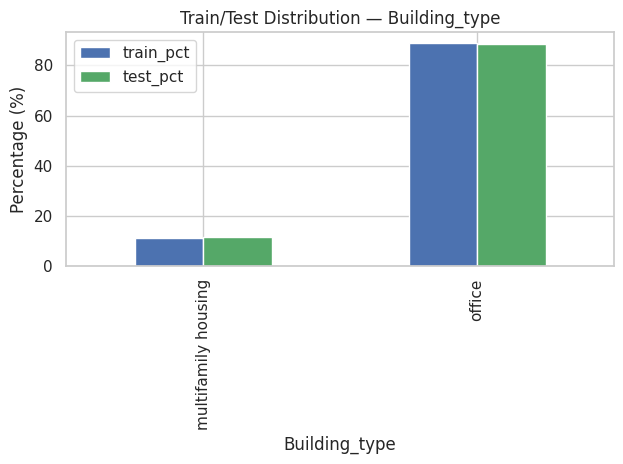

,train_count,test_count,train_pct,test_pct
cooling type,,,,
air conditioned,4467,1076,36.68,35.34
mixed mode,1832,486,15.04,15.96
naturally ventilated,5880,1483,48.28,48.70


<Figure size 700x400 with 0 Axes>

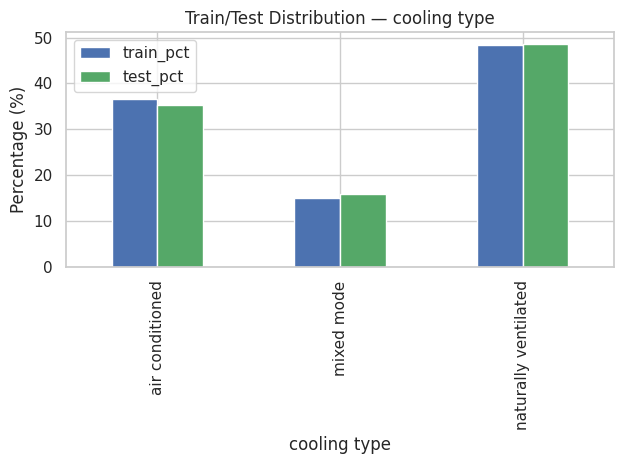

,train_count,test_count,train_pct,test_pct
Climate,,,,
Am,26,4,0.21,0.13
Aw,3544,870,29.10,28.57
BSh,1786,460,14.66,15.11
BSk,734,181,6.03,5.94
BWh,841,255,6.91,8.37
Cfa,2835,692,23.28,22.73
Cfb,1704,423,13.99,13.89
Dfb,709,160,5.82,5.25


<Figure size 700x400 with 0 Axes>

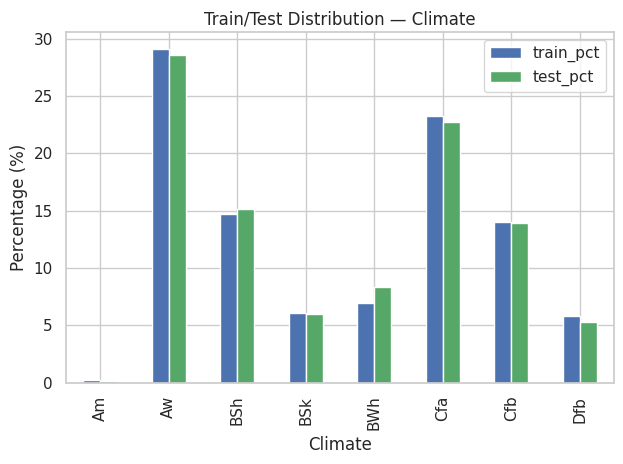


### NUMERICAL DISTRIBUTIONS ###

-- Tair --
{'train_mean': 24.639377918274626, 'test_mean': 24.714252873563215, 'train_std': 4.430753328885777, 'test_std': 4.426847123775333, 'mean_shift': 0.074874955288589}


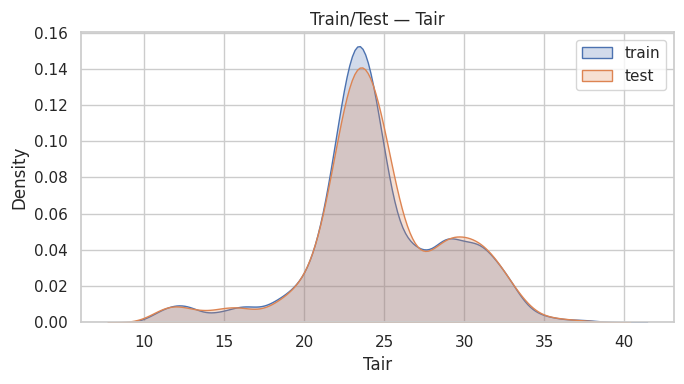


-- RH --
{'train_mean': 51.51417999836749, 'test_mean': 51.86712055301074, 'train_std': 16.304574235491124, 'test_std': 16.232653673537015, 'mean_shift': 0.35294055464325425}


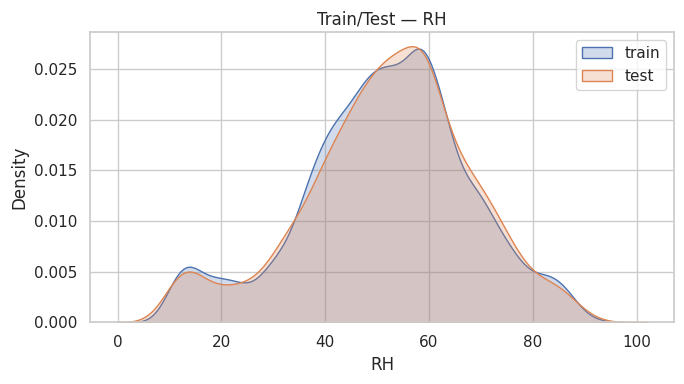


-- vel --
{'train_mean': 0.2417369923685222, 'test_mean': 0.24886536682664515, 'train_std': 0.3783946701539057, 'test_std': 0.4002233458634164, 'mean_shift': 0.007128374458122949}


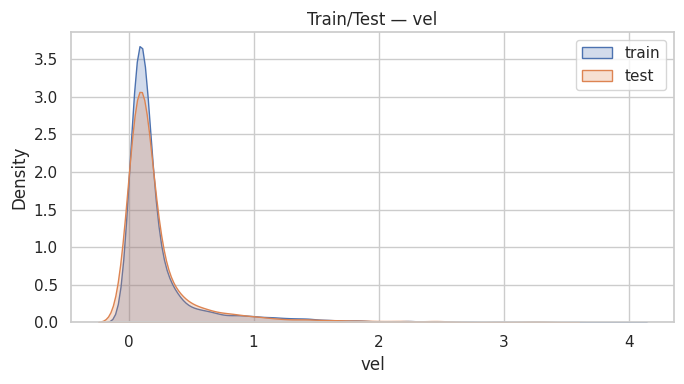


-- clo --
{'train_mean': 0.6607152176223711, 'test_mean': 0.6615668227553365, 'train_std': 0.30934787817271014, 'test_std': 0.3018500989967078, 'mean_shift': 0.0008516051329654495}


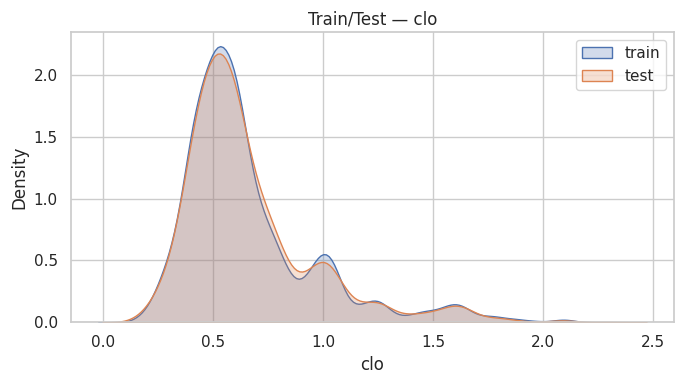


-- Met --
{'train_mean': 1.203468075509051, 'test_mean': 1.2024895794287958, 'train_std': 0.3014913944141335, 'test_std': 0.29626494731804465, 'mean_shift': -0.0009784960802552423}


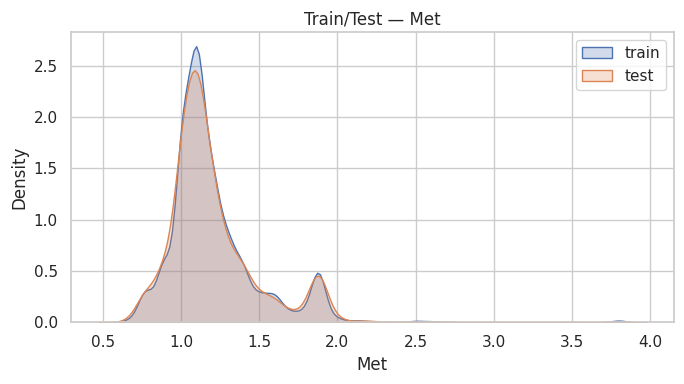


-- Tout --
{'train_mean': 21.991731383620255, 'test_mean': 22.124960299945265, 'train_std': 8.166035877793274, 'test_std': 8.002262634283719, 'mean_shift': 0.13322891632500955}


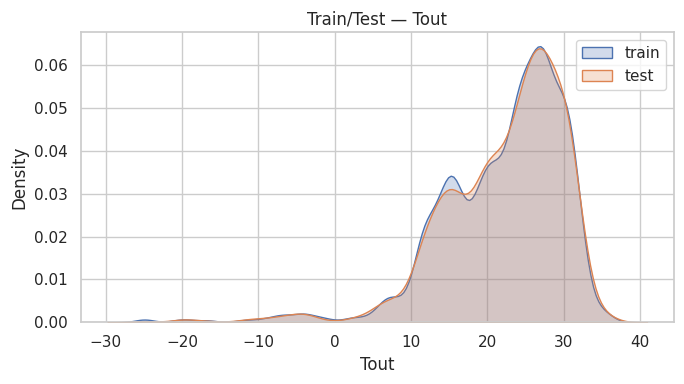


-- Trm_ema_28 --
{'train_mean': 21.12847657358554, 'test_mean': 21.251356961034276, 'train_std': 7.913904867682103, 'test_std': 7.826582640833067, 'mean_shift': 0.12288038744873475}


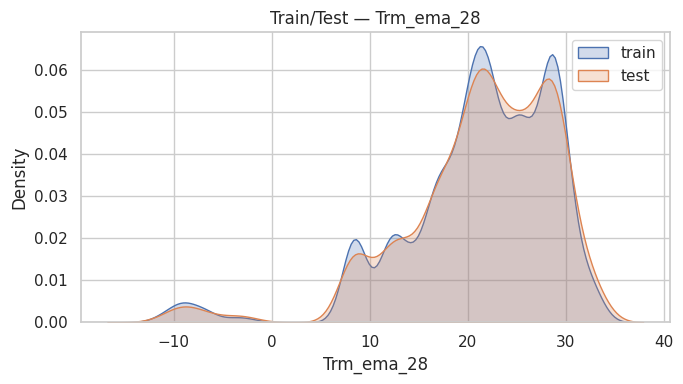


Saved results to: analysis/analysis_results_distributions/thermal_sensation

 TRAIN/TEST DISTRIBUTION — TSV_3p

### CATEGORICAL DISTRIBUTIONS ###


,train_count,test_count,train_pct,test_pct
Sexe,,,,
female,6141,1507,50.42,49.49
male,6038,1538,49.58,50.51


<Figure size 700x400 with 0 Axes>

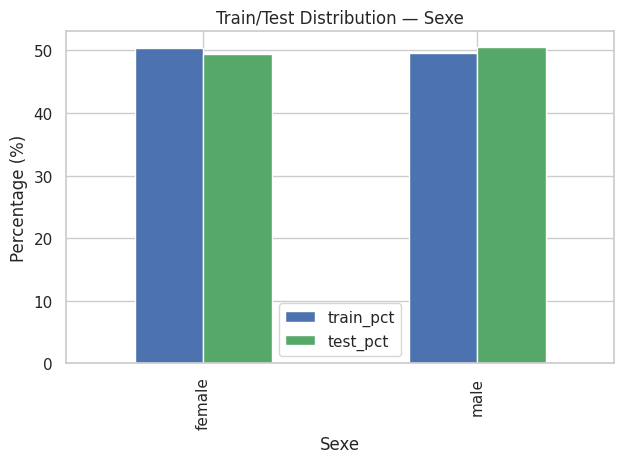

,train_count,test_count,train_pct,test_pct
Season,,,,
cool/dry,1529,394,12.55,12.94
hot/wet,1924,424,15.80,13.92
summer,5846,1474,48.00,48.41
winter,2880,753,23.65,24.73


<Figure size 700x400 with 0 Axes>

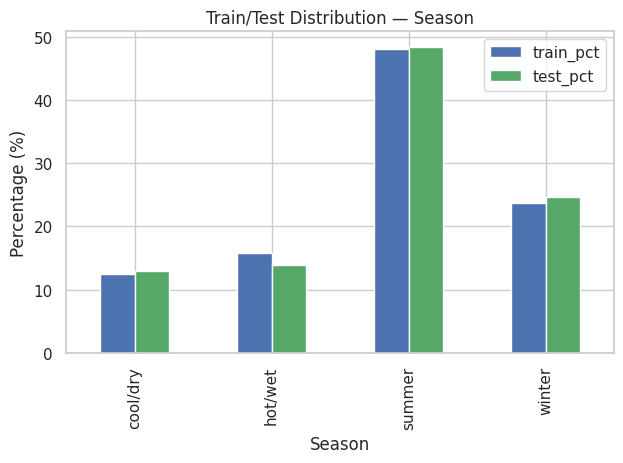

,train_count,test_count,train_pct,test_pct
Building_type,,,,
multifamily housing,1351,359,11.09,11.79
office,10828,2686,88.91,88.21


<Figure size 700x400 with 0 Axes>

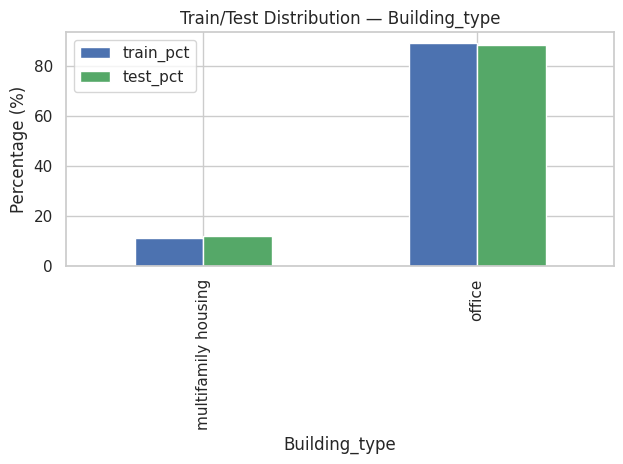

,train_count,test_count,train_pct,test_pct
cooling type,,,,
air conditioned,4494,1049,36.90,34.45
mixed mode,1822,496,14.96,16.29
naturally ventilated,5863,1500,48.14,49.26


<Figure size 700x400 with 0 Axes>

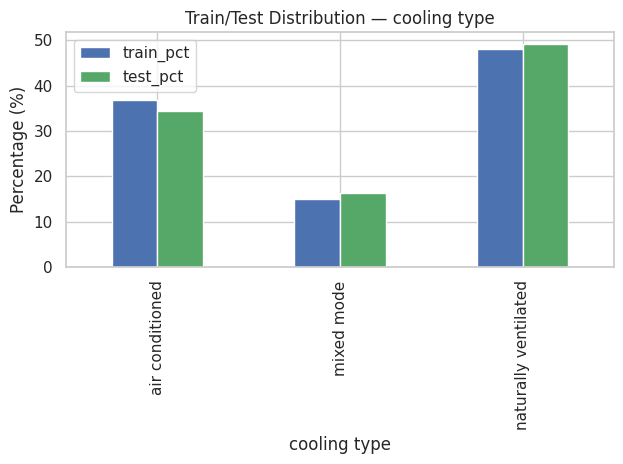

,train_count,test_count,train_pct,test_pct
Climate,,,,
Am,20,10,0.16,0.33
Aw,3572,842,29.33,27.65
BSh,1803,443,14.80,14.55
BSk,728,187,5.98,6.14
BWh,852,244,7.00,8.01
Cfa,2812,715,23.09,23.48
Cfb,1690,437,13.88,14.35
Dfb,702,167,5.76,5.48


<Figure size 700x400 with 0 Axes>

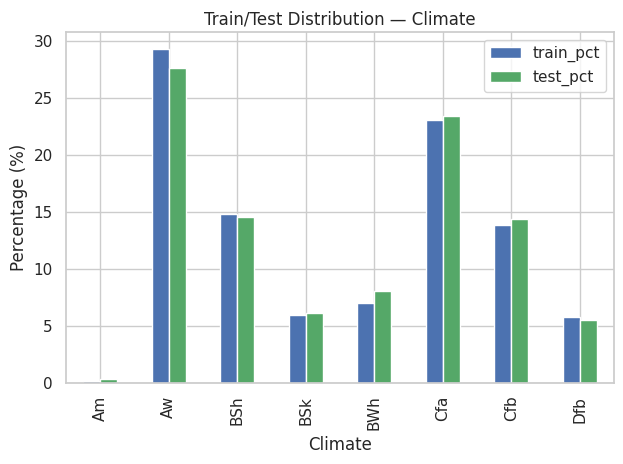


### NUMERICAL DISTRIBUTIONS ###

-- Tair --
{'train_mean': 24.65912499657881, 'test_mean': 24.63527104542967, 'train_std': 4.424017608293725, 'test_std': 4.45416869375984, 'mean_shift': -0.02385395114914246}


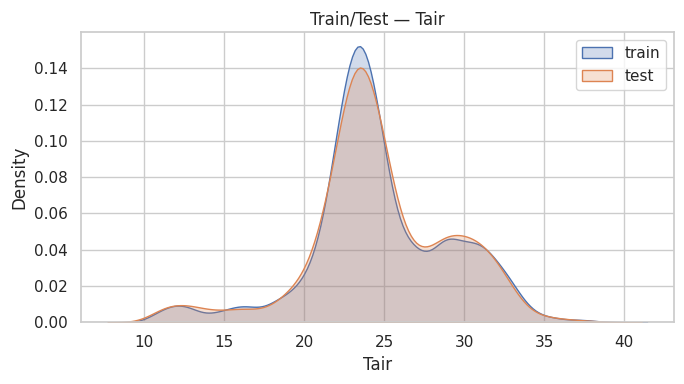


-- RH --
{'train_mean': 51.64997918235794, 'test_mean': 51.32396841448213, 'train_std': 16.26723103755021, 'test_std': 16.382301966358877, 'mean_shift': -0.3260107678758075}


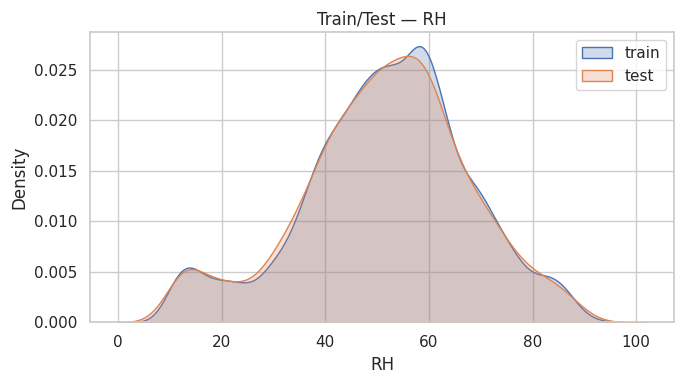


-- vel --
{'train_mean': 0.24094288053938032, 'test_mean': 0.25204155335115064, 'train_std': 0.378167504492235, 'test_std': 0.40100921156762015, 'mean_shift': 0.011098672811770322}


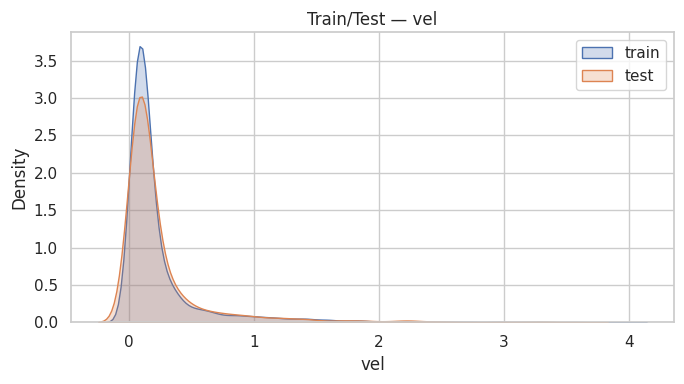


-- clo --
{'train_mean': 0.661940826430155, 'test_mean': 0.6566647900229884, 'train_std': 0.30811051799530287, 'test_std': 0.30683605090996485, 'mean_shift': -0.005276036407166562}


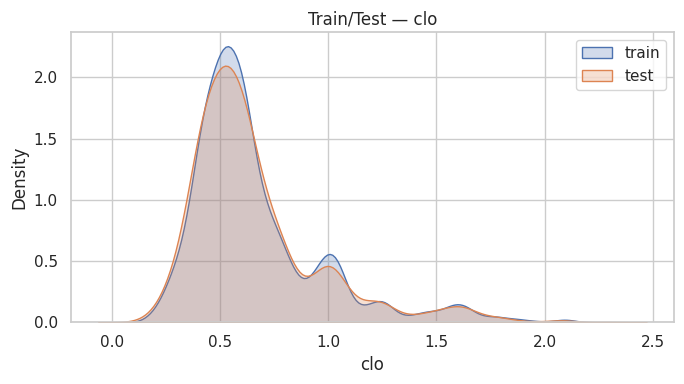


-- Met --
{'train_mean': 1.2039721876779306, 'test_mean': 1.2004732963073568, 'train_std': 0.3019447274982899, 'test_std': 0.2943968043208922, 'mean_shift': -0.003498891370573798}


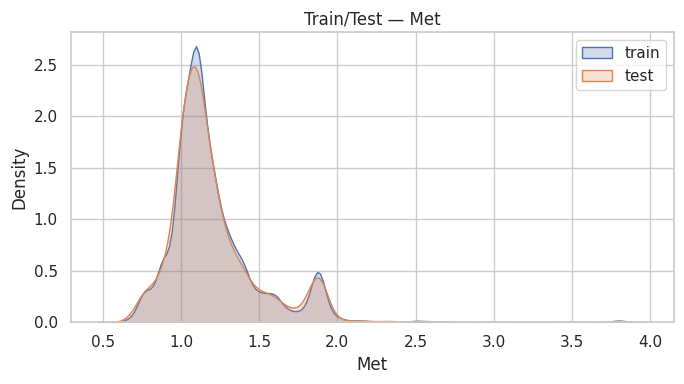


-- Tout --
{'train_mean': 22.06290533139922, 'test_mean': 21.840287882868086, 'train_std': 8.124279168934617, 'test_std': 8.168972956321207, 'mean_shift': -0.2226174485311354}


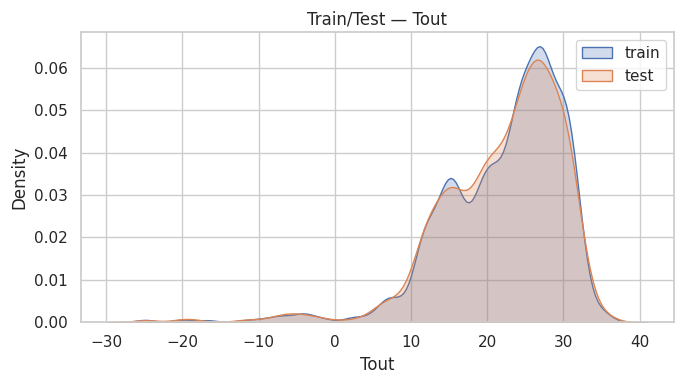


-- Trm_ema_28 --
{'train_mean': 21.191271799350044, 'test_mean': 21.000196680382096, 'train_std': 7.894739926347993, 'test_std': 7.902553287446563, 'mean_shift': -0.19107511896794804}


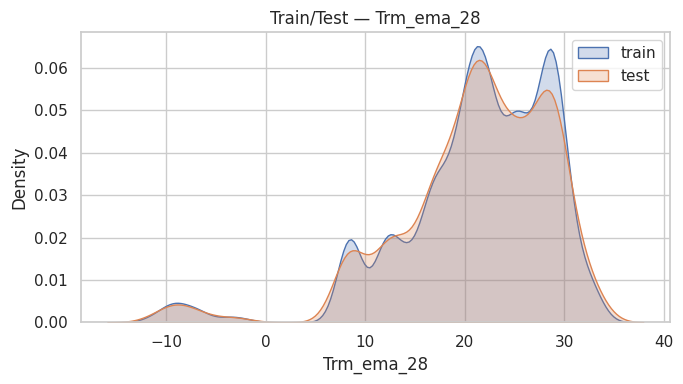


Saved results to: analysis/analysis_results_distributions/TSV_3p

 TRAIN/TEST DISTRIBUTION — thermal_preference

### CATEGORICAL DISTRIBUTIONS ###


,train_count,test_count,train_pct,test_pct
Sexe,,,,
female,6144,1504,50.45,49.39
male,6035,1541,49.55,50.61


<Figure size 700x400 with 0 Axes>

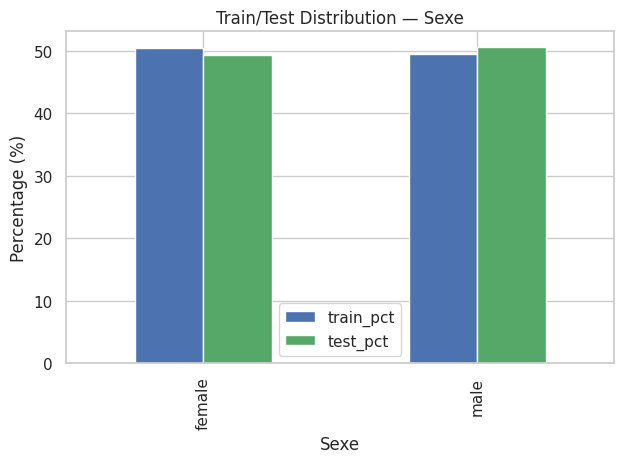

,train_count,test_count,train_pct,test_pct
Season,,,,
cool/dry,1529,394,12.55,12.94
hot/wet,1897,451,15.58,14.81
summer,5850,1470,48.03,48.28
winter,2903,730,23.84,23.97


<Figure size 700x400 with 0 Axes>

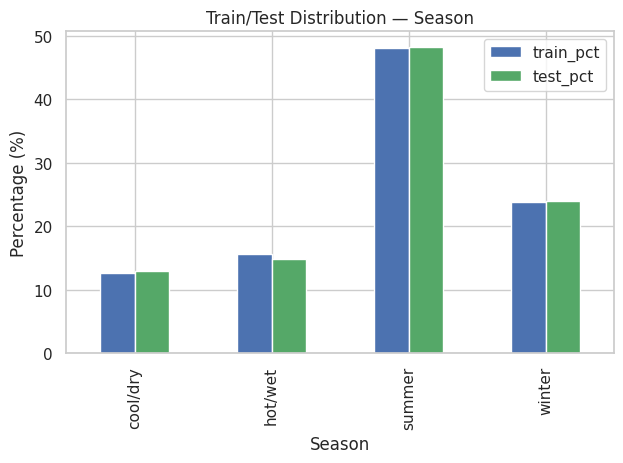

,train_count,test_count,train_pct,test_pct
Building_type,,,,
multifamily housing,1367,343,11.22,11.26
office,10812,2702,88.78,88.74


<Figure size 700x400 with 0 Axes>

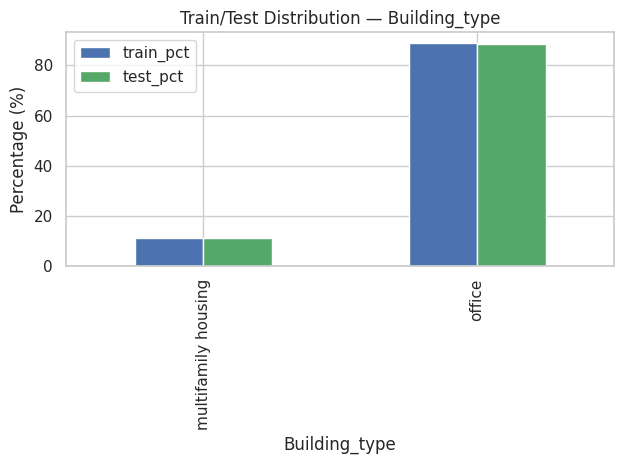

,train_count,test_count,train_pct,test_pct
cooling type,,,,
air conditioned,4463,1080,36.65,35.47
mixed mode,1849,469,15.18,15.40
naturally ventilated,5867,1496,48.17,49.13


<Figure size 700x400 with 0 Axes>

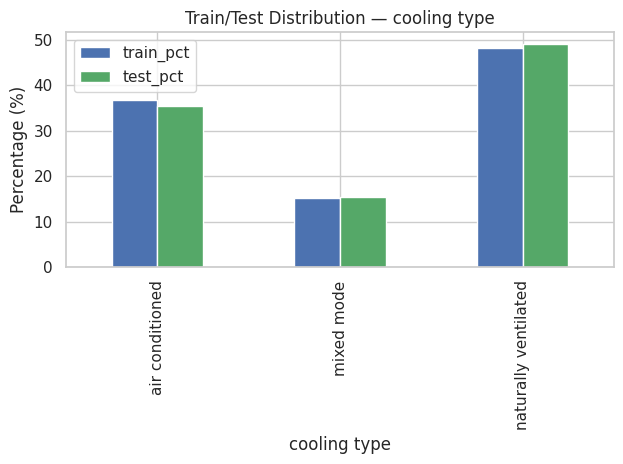

,train_count,test_count,train_pct,test_pct
Climate,,,,
Am,26,4,0.21,0.13
Aw,3536,878,29.03,28.83
BSh,1810,436,14.86,14.32
BSk,723,192,5.94,6.31
BWh,859,237,7.05,7.78
Cfa,2843,684,23.34,22.46
Cfb,1693,434,13.90,14.25
Dfb,689,180,5.66,5.91


<Figure size 700x400 with 0 Axes>

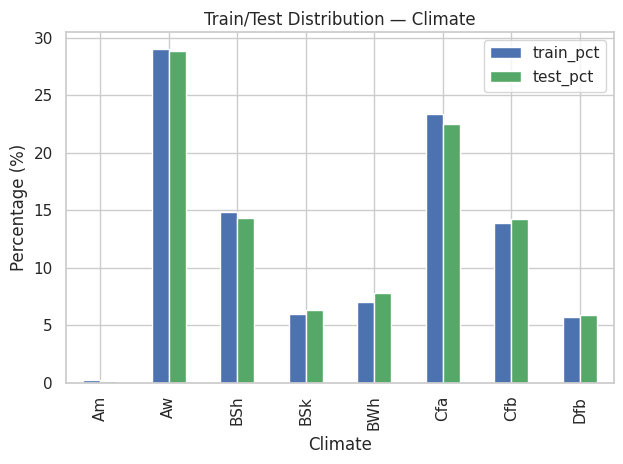


### NUMERICAL DISTRIBUTIONS ###

-- Tair --
{'train_mean': 24.63376278840627, 'test_mean': 24.73671154898741, 'train_std': 4.428808552186927, 'test_std': 4.434175375281509, 'mean_shift': 0.10294876058114255}


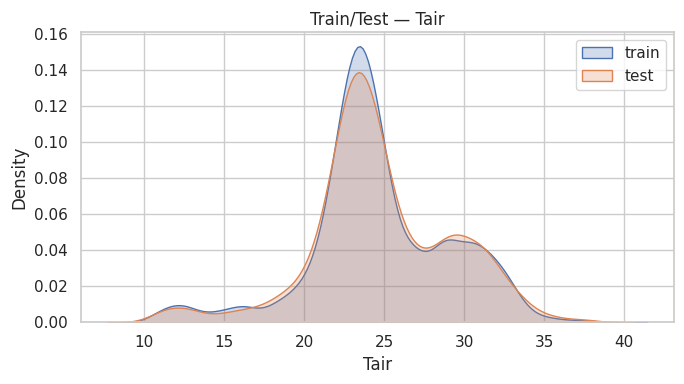


-- RH --
{'train_mean': 51.66866366002882, 'test_mean': 51.249236639916084, 'train_std': 16.23427149605522, 'test_std': 16.51089742704811, 'mean_shift': -0.41942702011273525}


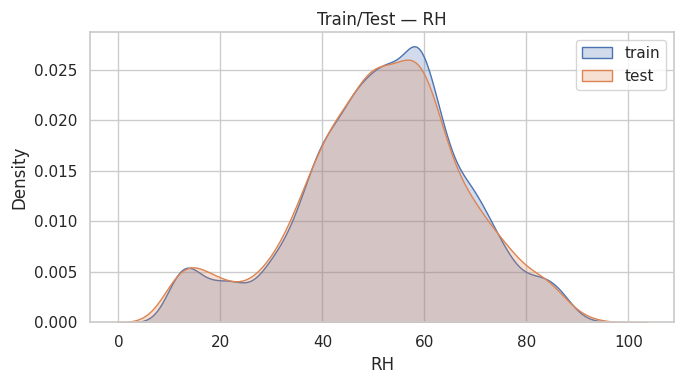


-- vel --
{'train_mean': 0.2430031829375781, 'test_mean': 0.24380102037655257, 'train_std': 0.38043912626027754, 'test_std': 0.39244394755262146, 'mean_shift': 0.0007978374389744636}


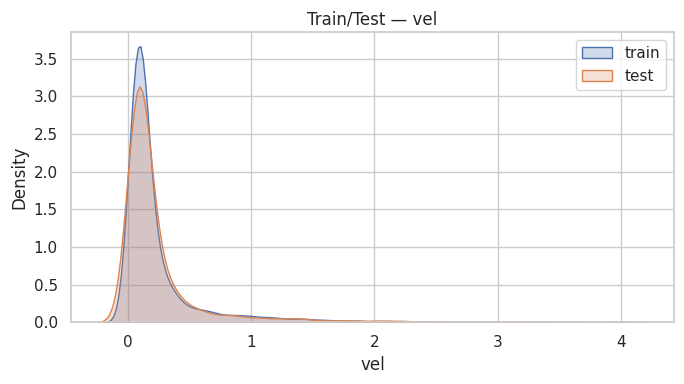


-- clo --
{'train_mean': 0.6625272782578913, 'test_mean': 0.6543191753070607, 'train_std': 0.3102831926723697, 'test_std': 0.2978952281664212, 'mean_shift': -0.00820810295083052}


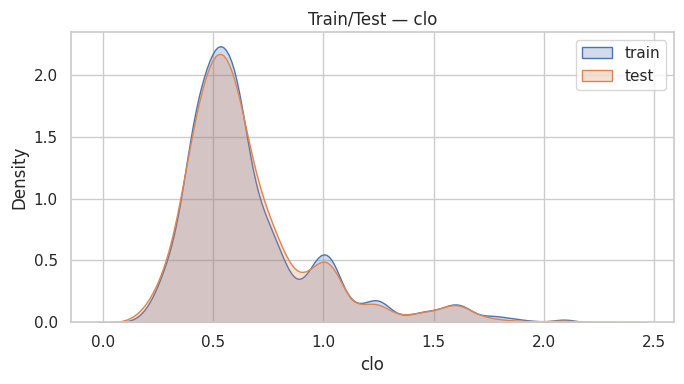


-- Met --
{'train_mean': 1.2029313075613954, 'test_mean': 1.204636474940947, 'train_std': 0.29640217548012565, 'test_std': 0.31614016311468957, 'mean_shift': 0.0017051673795516198}


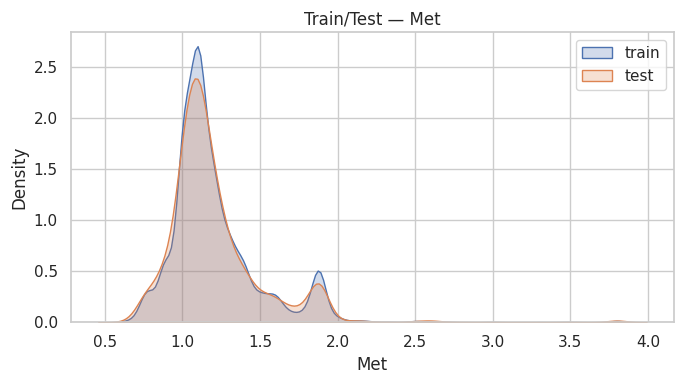


-- Tout --
{'train_mean': 22.02232953143389, 'test_mean': 22.00257775734355, 'train_std': 8.105535032675894, 'test_std': 8.245515231127037, 'mean_shift': -0.019751774090341456}


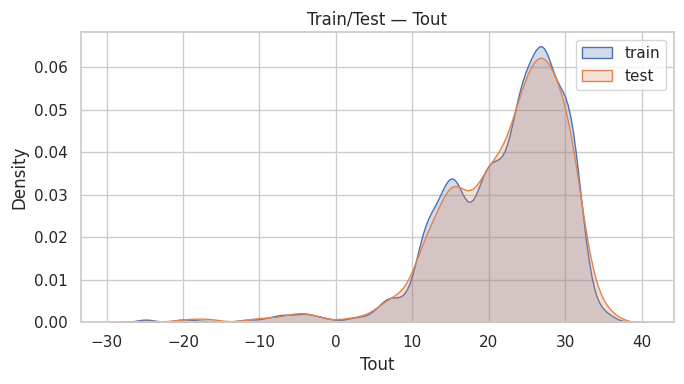


-- Trm_ema_28 --
{'train_mean': 21.15869838162716, 'test_mean': 21.130479653927893, 'train_std': 7.866657729678182, 'test_std': 8.015589659370173, 'mean_shift': -0.028218727699268698}


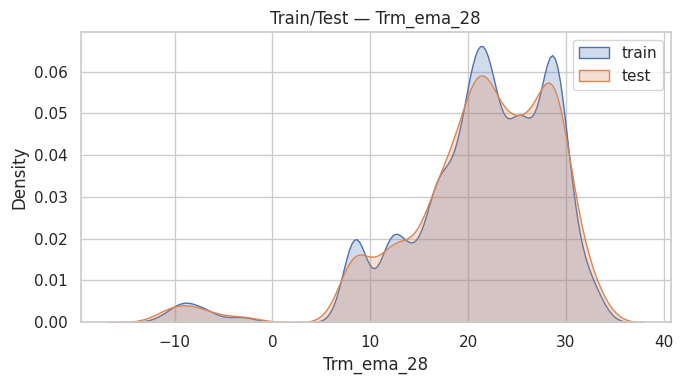


Saved results to: analysis/analysis_results_distributions/thermal_preference


{'thermal_sensation': {'target': 'thermal_sensation',
  'categorical': {'Sexe': {'train_count': {'female': 6123, 'male': 6056},
    'test_count': {'female': 1525, 'male': 1520},
    'train_pct': {'female': 50.28, 'male': 49.72},
    'test_pct': {'female': 50.08, 'male': 49.92}},
   'Season': {'train_count': {'cool/dry': 1532,
     'hot/wet': 1894,
     'summer': 5849,
     'winter': 2904},
    'test_count': {'cool/dry': 391,
     'hot/wet': 454,
     'summer': 1471,
     'winter': 729},
    'train_pct': {'cool/dry': 12.58,
     'hot/wet': 15.55,
     'summer': 48.03,
     'winter': 23.84},
    'test_pct': {'cool/dry': 12.84,
     'hot/wet': 14.91,
     'summer': 48.31,
     'winter': 23.94}},
   'Building_type': {'train_count': {'multifamily housing': 1366,
     'office': 10813},
    'test_count': {'multifamily housing': 344, 'office': 2701},
    'train_pct': {'multifamily housing': 11.22, 'office': 88.78},
    'test_pct': {'multifamily housing': 11.3, 'office': 88.7}},
   'cooling typ

In [16]:
df = pd.read_csv(DATASET_PATH)

all_results = {}

for target in TARGETS:
    all_results[target] = run_distribution_analysis(df, target)

with open(OUTPUT_BASE / "global_summary.json", "w") as f:
    json.dump(all_results, f, indent=4)

all_results
